# Age-Structured SEIHRV Model

Want to rewrite the existing SEIHRVD model, but using a class, `SEIHRVDsim`.

This then allows you to pass it in different parameters - depending on the age group (0-19, 20-64, 65+) - and produce the respective model. You can still vary vaccine time and efficacy, as well as lockdown duration just before you run the simulation. All other parameters are stored in the file `params.json` which is opened and split into `youngAgeGrp`, `adultAgeGrp`, `elderlyAgeGrp`. You then choose which to input as the first parameter when running the simulation.

The parameters that vary with age are:

- $d$ (probability of displaying symptoms)
- $h$ (probability of hospitalisation given symptomatic)
- $k$ (probability of death given hospitalisation)
- $compliance$ (value that lockdown divides transmission by)
- $N$ (population size)
- $S_0, E_0, I_0^S, I_0^A,$ (non-zero initial values (defined as 99.9%, 0.05%, 0.025%, 0.025% of $N$ respectively))

As expected, the three probabilities are all highest in the elderly, who are most at risk. $d$ and $k$ are lowest in the youngest group (ages 0 to 19), whereas $h$ is (just) lowest in the adult group.

The age groups (data from the ONS) are:

- **0 to 19 years:** $15,546,000$ people in the UK - 22.3% of population
- **20 to 64 years:** $40,668,000$ people in the UK - 58.4% of population
- **65+ years:** $13,415,000$ people in the UK - 19.3% of population




In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi
import json
from types import SimpleNamespace
import math

In [3]:
# Opening the params file and separating it into our three age categories

f = open("params.json", "r")
contents = f.read()
f.close()


params = json.loads(contents)

youngAgeGrp = params['0-19']
adultAgeGrp = params['20-64']
elderlyAgeGrp = params['65+']

## One lockdown

In [443]:
class SEIHRVDsim_1LD:
    
    def __init__(self, ageGrpParams, vaccineStart, eta, lockdown1Start, lockdown1End):
        self.params = SimpleNamespace(**ageGrpParams)
        self.params.vaccineStart = vaccineStart
        self.params.eta = eta
        self.params.lockdown1Start = lockdown1Start
        self.params.lockdown1End = lockdown1End

        self.InitialVals = [self.params.S_U0, self.params.E_U0, self.params.I_SU0, self.params.I_AU0, self.params.H_U0, self.params.R_U0, self.params.D_U0, self.params.S_V0, self.params.S_VI0, self.params.E_V0, self.params.I_SV0, self.params.I_AV0, self.params.H_V0, self.params.R_V0, self.params.D_V0]
        
    def betaFunc(self,time):
        if self.params.lockdown1Start < time <= self.params.lockdown1End:
            newBeta = (self.params.beta/self.params.compliance)*(1 + (self.params.compliance - 1)*np.exp(-(time - self.params.lockdown1Start)))
        elif time > self.params.lockdown1End:
            newBeta = self.params.beta + (self.params.beta*(1-self.params.compliance)/self.params.compliance)*np.exp(-self.params.easing*(time - self.params.lockdown1End))
        else:
            newBeta = self.params.beta
        return newBeta
    
    def SEIHRDmodel(self, IVS,time):  

        FOI = self.betaFunc(time)*(self.params.tau*IVS[3] + IVS[2] + self.params.rho*IVS[4])

        S_U  = self.params.omega*IVS[5] - FOI*IVS[0]/self.params.N
        E_U  = FOI*IVS[0]/self.params.N - self.params.epsilon*IVS[1]
        I_SU = self.params.epsilon*self.params.d*IVS[1] - self.params.gamma*IVS[2]
        I_AU = self.params.epsilon*(1-self.params.d)*IVS[1] - self.params.gamma*IVS[3]
        H_U  = self.params.gamma*self.params.h*IVS[2] - self.params.delta*IVS[4]
        R_U  = self.params.delta*(1-self.params.k)*IVS[4] + self.params.gamma*(1-self.params.h)*IVS[2] + self.params.gamma*IVS[3] - self.params.omega*IVS[5]
        D_U  = self.params.delta*self.params.k*IVS[4]

        S_V  = 0
        S_VI = 0
        E_V  = 0
        I_SV = 0
        I_AV = 0
        H_V  = 0
        R_V  = 0
        D_V  = 0

        Y = [S_U, E_U, I_SU, I_AU, H_U, R_U, D_U, S_V, S_VI, E_V, I_SV, I_AV, H_V, R_V, D_V]
        return(Y) 

    def SEIHRVDmodel(self,IVS,time): 

        FOI = self.betaFunc(time)*(self.params.tau*(IVS[3] + IVS[11]) + IVS[2] + IVS[10] + self.params.rho*(IVS[4] + IVS[12]))

        S_U  = self.params.omega*IVS[5] - FOI*IVS[0]/self.params.N - self.params.sigma*IVS[0]
        E_U  = FOI*IVS[0]/self.params.N - self.params.epsilon*IVS[1]
        I_SU = self.params.epsilon*self.params.d*IVS[1] - self.params.gamma*IVS[2]
        I_AU = self.params.epsilon*(1-self.params.d)*IVS[1] - self.params.gamma*IVS[3]
        H_U  = self.params.gamma*self.params.h*IVS[2] - self.params.delta*IVS[4]
        R_U  = self.params.delta*(1-self.params.k)*IVS[4] + self.params.gamma*(1-self.params.h)*IVS[2] + self.params.gamma*IVS[3] - self.params.omega*IVS[5]
        D_U  = self.params.delta*self.params.k*IVS[4]

        S_V  = self.params.omega*IVS[13] - FOI*IVS[7]/self.params.N + self.params.sigma*(1-self.params.eta)*IVS[0]
        S_VI = self.params.sigma*self.params.eta*IVS[0]
        E_V  = FOI*IVS[7]/self.params.N - self.params.epsilon*IVS[9]
        I_SV = self.params.epsilon*self.params.d*IVS[9] - self.params.gamma*IVS[10]
        I_AV = self.params.epsilon*(1-self.params.d)*IVS[9] - self.params.gamma*IVS[11]
        H_V  = self.params.gamma*self.params.h*IVS[10] - self.params.delta*IVS[12]
        R_V  = self.params.delta*(1-self.params.k)*IVS[12] + self.params.gamma*(1-self.params.h)*IVS[10] + self.params.gamma*IVS[11] - self.params.omega*IVS[13]
        D_V  = self.params.delta*self.params.k*IVS[12]

        Y = [S_U, E_U, I_SU, I_AU, H_U, R_U, D_U, S_V, S_VI, E_V, I_SV, I_AV, H_V, R_V, D_V]
        return(Y)
    
    def ODEsolver(self):
        t1 = np.arange(self.params.t_start, self.params.vaccineStart, self.params.t_step) # time up until vaccine implemented
        t2 = np.arange(self.params.vaccineStart - self.params.t_step, self.params.days + self.params.t_step, self.params.t_step) # time after vaccine implemented
        values1 = spi.odeint(self.SEIHRDmodel, self.InitialVals, t1) # pre-vaccine 
        values2 = spi.odeint(self.SEIHRVDmodel, values1[-1], t2) # post-vaccine

        total_values = np.concatenate((values1, values2[1:]), axis = 0) # Combining pre- and post- vaccine info

        # Getting the totals
        total_susceptible = total_values[:,0] + total_values[:,7]
        total_exposed = total_values[:,1] + total_values[:,9]
        total_infected = total_values[:,2] + total_values[:,3] + total_values[:,10]+ total_values[:,11] #combining A and S
        total_hospitalised = total_values[:,4] + total_values[:,12]
        total_recovered = total_values[:,5] + total_values[:,13]
        total_dead = total_values[:,6] + total_values[:, 14]
        total_vaccinated = total_values[:,7]+ total_values[:,8] + total_values[:,9]+ total_values[:,10] + total_values[:,11]+ total_values[:,12] + total_values[:,13]+ total_values[:,14]
        self.totals = [total_susceptible, total_exposed, total_infected, total_hospitalised, total_recovered, total_dead, total_vaccinated]
        self.vaccinated_immune = total_values[:,8]
        
        return(self.totals, self.vaccinated_immune)
    
    def outbreakEndResults(self): #returns final (total) hospitalisations, deaths, and vaccinations
        newDailyNumberOfHospitalisations = self.params.gamma*self.params.h*self.ODEsolver()[0][2]
        print("Over the course of the outbreak,",math.ceil(sum(newDailyNumberOfHospitalisations)), "people were hospitalised")
        print("Over the course of the outbreak,",math.ceil(self.ODEsolver()[0][5][-1]), "people died.")
        print("Since vaccination was deployed on day", vaccineStart,"," , math.ceil(self.ODEsolver()[0][6][-1]), "people have been vaccinated -", math.ceil(self.ODEsolver()[1][-1]), "successfully.")   
        

I have made it so that you can call the `ODEsolver()` function, which will return the total values of all the compartments (ie vaccinated + unvaccinated), as well as the number of vaccinated immune people (mainly so it can be called in the next function).

You can also call `outbreakEndResults()`, which will give the total number of hospitalisations and deaths at the end of the outbreak - as well as how many people were vaccinated and how many of them were then immune (dependent on efficacy $\eta$).

I want to be able to implement vaccine deployment at different times depending on age group - where the elderly are prioritised, then adults, then children. When 50% of the elderly have been vaccinated, we then rollout adult vaccinations. When 50% of adults have been vaccinated, we can rollout vaccines for children. This is done by the function `vaccinationDay()`, where you give it the age group that needs to reach 50% vaccinated, and the day that they start vaccinating as parameters.

That means we now have 3 different vaccine deployment times to give to the three age group objects.

We can then create these three objects and call the `ODEsolver()` function - this will give the values that can then be plotted. Since I am plotting all three age groups on one graph, I have simplified the lines to just total (no vaccinated vs unvaccinated, or asymptomatic vs symptomatic) to avoid too many lines.

I also print the final number of hospitalisations, deaths, and vaccinations by calling `outbreakEndResults()`.

For those 0-19 years old:
Over the course of the outbreak, 34584 people were hospitalised
Over the course of the outbreak, 27 people died.
Since vaccination was deployed on day 20 , 13271971 people have been vaccinated - 7963183 successfully.
--------------------------
For those 20-64 years old:
Over the course of the outbreak, 459187 people were hospitalised
Over the course of the outbreak, 3296 people died.
Since vaccination was deployed on day 20 , 36536125 people have been vaccinated - 21921675 successfully.
--------------------------
For those aged 65+:
Over the course of the outbreak, 2009128 people were hospitalised
Over the course of the outbreak, 205493 people died.
Since vaccination was deployed on day 20 , 12582901 people have been vaccinated - 7549741 successfully.


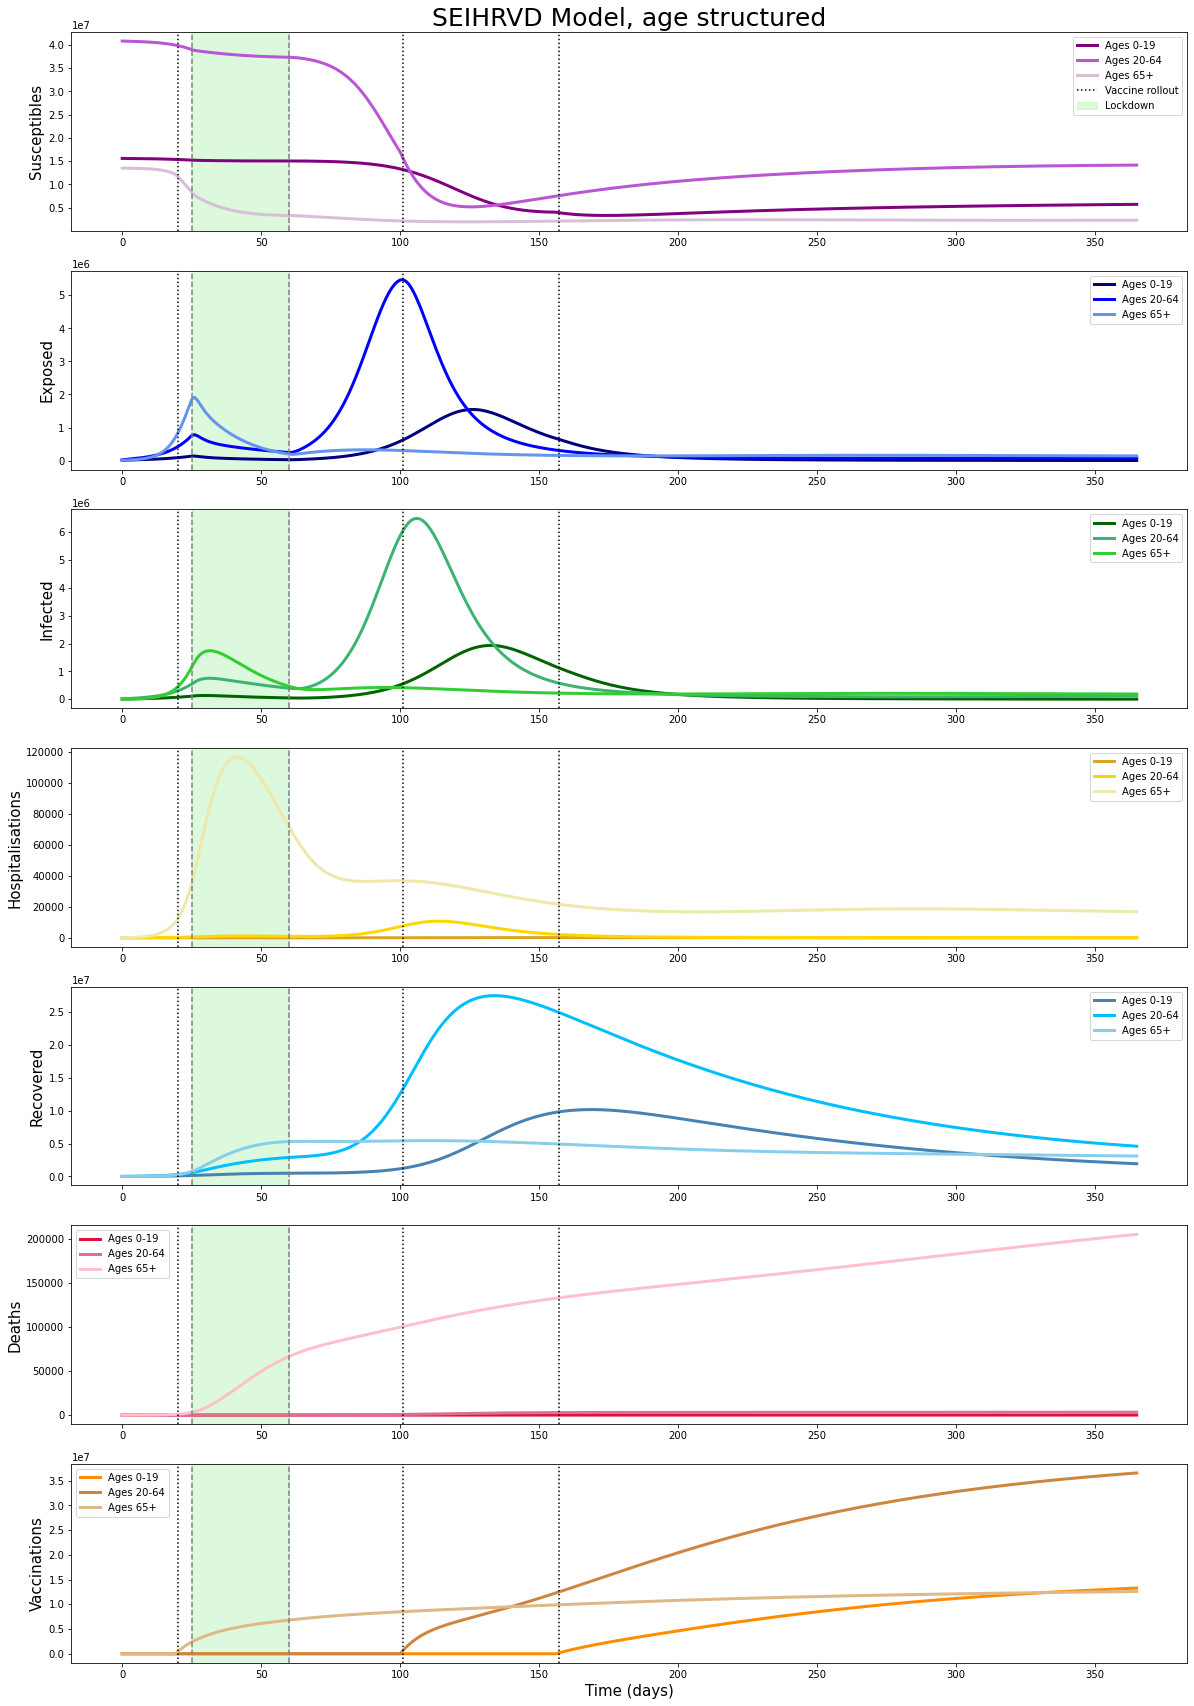

In [444]:
# Function to determine when vaccination should be rolled out for the given group 
def vaccinationDay(ageGrp, vaccineStart):
    sim = SEIHRVDsim_1LD(ageGrp, vaccineStart, eta, lockdown1Start, lockdown1End)

    totals, vaccImmune = sim.ODEsolver()
    
    dayToVaccinate = 0
    for day in range(ageGrp['days']):
        if totals[6][day] < 0.5*ageGrp['N']: # if number of vaccinations on  
            dayToVaccinate += 1

    return(dayToVaccinate)


# Parameters for intervention measures:
eta = 0.6
lockdownStart = 25
lockdownEnd = 60
vaccineStart = 20
adultsVaccine = vaccinationDay(elderlyAgeGrp, vaccineStart)
childrenVaccine = vaccinationDay(adultAgeGrp, adultsVaccine)

# Creating the objects for 3 different age groups
elderlySim = SEIHRVDsim_1LD(elderlyAgeGrp, vaccineStart, eta, lockdownStart, lockdownEnd)
adultSim = SEIHRVDsim_1LD(adultAgeGrp, adultsVaccine, eta, lockdownStart, lockdownEnd)
youngSim = SEIHRVDsim_1LD(youngAgeGrp, childrenVaccine, eta, lockdownStart, lockdownEnd)
totalsY, vaccImmuneY = youngSim.ODEsolver()
totalsA, vaccImmuneA = adultSim.ODEsolver()
totalsE, vaccImmuneE = elderlySim.ODEsolver()


# Outbreak final numbers
print("For those 0-19 years old:")
youngSim.outbreakEndResults()
print("--------------------------")
print("For those 20-64 years old:")
adultSim.outbreakEndResults()
print("--------------------------")
print("For those aged 65+:")
elderlySim.outbreakEndResults()


# PLOTTING:
plt.figure(figsize=(20, 30))

plt.subplot(711) # SUSCEPTIBLES
plt.plot(totalsY[0], 'purple', linewidth = 3, label = 'Ages 0-19')
plt.plot(totalsA[0], 'mediumorchid', linewidth = 3, label = 'Ages 20-64')
plt.plot(totalsE[0], 'thistle', linewidth = 3, label = 'Ages 65+')
plt.axvline(vaccineStart, color = 'black', linestyle='dotted', label = 'Vaccine rollout')
plt.axvline(adultsVaccine, color = 'black', linestyle='dotted')
plt.axvline(childrenVaccine, color = 'black', linestyle='dotted')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen', label = 'Lockdown')
plt.title('SEIHRVD Model, age structured', fontsize=25)
plt.legend(loc=0)
plt.ylabel('Susceptibles', fontsize=15)

plt.subplot(712) # EXPOSED
plt.plot(totalsY[1], 'navy', linewidth=3, label = 'Ages 0-19')
plt.plot(totalsA[1], 'blue', linewidth = 3, label='Ages 20-64')
plt.plot(totalsE[1], 'cornflowerblue', linewidth = 3, label='Ages 65+')
plt.axvline(vaccineStart, color = 'black', linestyle='dotted')
plt.axvline(adultsVaccine, color = 'black', linestyle='dotted')
plt.axvline(childrenVaccine, color = 'black', linestyle='dotted')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Exposed', fontsize=15)

plt.subplot(713) # INFECTIOUS
plt.plot(totalsY[2], 'darkgreen', linewidth=3, label = 'Ages 0-19')
plt.plot(totalsA[2], 'mediumseagreen', linewidth = 3, label = 'Ages 20-64')
plt.plot(totalsE[2], 'limegreen', linewidth = 3, label = 'Ages 65+')
plt.axvline(vaccineStart, color = 'black', linestyle='dotted')
plt.axvline(adultsVaccine, color = 'black', linestyle='dotted')
plt.axvline(childrenVaccine, color = 'black', linestyle='dotted')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Infected', fontsize=15)

plt.subplot(714) #HOSPITALISED
plt.plot(totalsY[3], 'goldenrod', linewidth=3, label = 'Ages 0-19')
plt.plot(totalsA[3], 'gold', linewidth = 3, label = 'Ages 20-64')
plt.plot(totalsE[3], 'palegoldenrod', linewidth = 3, label = 'Ages 65+')
plt.axvline(vaccineStart, color = 'black', linestyle='dotted')
plt.axvline(adultsVaccine, color = 'black', linestyle='dotted')
plt.axvline(childrenVaccine, color = 'black', linestyle='dotted')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Hospitalisations', fontsize=15)

plt.subplot(715) # RECOVERED
plt.plot(totalsY[4], 'steelblue', linewidth=3, label = 'Ages 0-19')
plt.plot(totalsA[4], 'deepskyblue', linewidth = 3, label = 'Ages 20-64')
plt.plot(totalsE[4], 'skyblue', linewidth = 3, label = 'Ages 65+')
plt.axvline(vaccineStart, color = 'black', linestyle = 'dotted')
plt.axvline(adultsVaccine, color = 'black', linestyle='dotted')
plt.axvline(childrenVaccine, color = 'black', linestyle='dotted')
plt.axvline(lockdownStart, color = 'grey', linestyle = 'dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle = 'dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Recovered', fontsize=15)

plt.subplot(716) # DEAD
plt.plot(totalsY[5], 'crimson', linewidth=3, label = 'Ages 0-19')
plt.plot(totalsA[5], 'palevioletred', linewidth = 3, label='Ages 20-64')
plt.plot(totalsE[5], 'pink', linewidth = 3, label='Ages 65+')
plt.axvline(vaccineStart, color = 'black', linestyle='dotted')
plt.axvline(adultsVaccine, color = 'black', linestyle='dotted')
plt.axvline(childrenVaccine, color = 'black', linestyle='dotted')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Deaths', fontsize=15)

plt.subplot(717) # VACCINATED
plt.plot(totalsY[6], 'darkorange', linewidth = 3, label='Ages 0-19')
plt.plot(totalsA[6], 'peru', linewidth = 3, label='Ages 20-64')
plt.plot(totalsE[6], 'burlywood', linewidth = 3, label='Ages 65+')
plt.axvline(vaccineStart, color = 'black', linestyle='dotted')
plt.axvline(adultsVaccine, color = 'black', linestyle='dotted')
plt.axvline(childrenVaccine, color = 'black', linestyle='dotted')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.xlabel('Time (days)', fontsize=15)
plt.ylabel('Vaccinations', fontsize = 15)

plt.show()

## Adding two lockdowns

I now want to add the option of a second lockdown, so I have changed the parameters to `lockdown1Start/End` and `lockdown2Start/End`. For this to work we require the (logical) assumption that:

`lockdown1Start` < `lockdown1End` < `lockdown2Start` < `lockdown2End`

The only other edit this makes to the code is that the function defining the new beta for lockdown needs two more `elif` statements. This code can be used from now on (instead of the SEIHRVDsim_1LD) as you can just set `lockdown2Start` = `lockdown2End` = 0 if needed.

Also: I noticed that my hospitalisations curve was plotting the number in hospital at any one time, as opposed to the new daily number of hospitalisations. I have edited the `ODEsolver` function within the class so that it can now output the daily hospitalisations too, so when plotting hospitalisations there are now two options:

- `totalsX[3]`: the total number of people (in age grp X) in hospital at that time
- `hospitalisationsX`: the new number of people (in age grp X) who have entered hospital at that time

In [9]:
class SEIHRVDsim_2LD:
    
    def __init__(self, ageGrpParams, vaccineStart, eta, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End):
        self.params = SimpleNamespace(**ageGrpParams)
        self.params.vaccineStart = vaccineStart
        self.params.eta = eta
        self.params.lockdown1Start = lockdown1Start
        self.params.lockdown1End = lockdown1End
        self.params.lockdown2Start = lockdown2Start
        self.params.lockdown2End = lockdown2End
        
        self.InitialVals = [self.params.S_U0, self.params.E_U0, self.params.I_SU0, self.params.I_AU0, self.params.H_U0, self.params.R_U0, self.params.D_U0, self.params.S_V0, self.params.S_VI0, self.params.E_V0, self.params.I_SV0, self.params.I_AV0, self.params.H_V0, self.params.R_V0, self.params.D_V0]
        
    def betaFunc(self,time):
        if self.params.lockdown1Start < time <= self.params.lockdown1End:
            newBeta = (self.params.beta/self.params.compliance)*(1 + (self.params.compliance - 1)*np.exp(-(time - self.params.lockdown1Start)))
        elif self.params.lockdown2Start < time <= self.params.lockdown2End:
            newBeta = (self.params.beta/self.params.compliance)*(1 + (self.params.compliance - 1)*np.exp(-(time - self.params.lockdown2Start)))
        elif self.params.lockdown1End < time <= self.params.lockdown2Start:
            newBeta = self.params.beta + (self.params.beta*(1-self.params.compliance)/self.params.compliance)*np.exp(-self.params.easing*(time - self.params.lockdown1End))
        elif time > self.params.lockdown2End:
            newBeta = self.params.beta + (self.params.beta*(1-self.params.compliance)/self.params.compliance)*np.exp(-self.params.easing*(time - self.params.lockdown2End))
        else:
            newBeta = self.params.beta
        return newBeta
    
    def SEIHRDmodel(self, IVS,time):  

        FOI = self.betaFunc(time)*(self.params.tau*IVS[3] + IVS[2] + self.params.rho*IVS[4])

        S_U  = self.params.omega*IVS[5] - FOI*IVS[0]/self.params.N
        E_U  = FOI*IVS[0]/self.params.N - self.params.epsilon*IVS[1]
        I_SU = self.params.epsilon*self.params.d*IVS[1] - self.params.gamma*IVS[2]
        I_AU = self.params.epsilon*(1-self.params.d)*IVS[1] - self.params.gamma*IVS[3]
        H_U  = self.params.gamma*self.params.h*IVS[2] - self.params.delta*IVS[4]
        R_U  = self.params.delta*(1-self.params.k)*IVS[4] + self.params.gamma*(1-self.params.h)*IVS[2] + self.params.gamma*IVS[3] - self.params.omega*IVS[5]
        D_U  = self.params.delta*self.params.k*IVS[4]

        S_V  = 0
        S_VI = 0
        E_V  = 0
        I_SV = 0
        I_AV = 0
        H_V  = 0
        R_V  = 0
        D_V  = 0

        Y = [S_U, E_U, I_SU, I_AU, H_U, R_U, D_U, S_V, S_VI, E_V, I_SV, I_AV, H_V, R_V, D_V]
        return(Y) 

    def SEIHRVDmodel(self,IVS,time): 

        FOI = self.betaFunc(time)*(self.params.tau*(IVS[3] + IVS[11]) + IVS[2] + IVS[10] + self.params.rho*(IVS[4] + IVS[12]))

        S_U  = self.params.omega*IVS[5] - FOI*IVS[0]/self.params.N - self.params.sigma*IVS[0]
        E_U  = FOI*IVS[0]/self.params.N - self.params.epsilon*IVS[1]
        I_SU = self.params.epsilon*self.params.d*IVS[1] - self.params.gamma*IVS[2]
        I_AU = self.params.epsilon*(1-self.params.d)*IVS[1] - self.params.gamma*IVS[3]
        H_U  = self.params.gamma*self.params.h*IVS[2] - self.params.delta*IVS[4]
        R_U  = self.params.delta*(1-self.params.k)*IVS[4] + self.params.gamma*(1-self.params.h)*IVS[2] + self.params.gamma*IVS[3] - self.params.omega*IVS[5]
        D_U  = self.params.delta*self.params.k*IVS[4]

        S_V  = self.params.omega*IVS[13] - FOI*IVS[7]/self.params.N + self.params.sigma*(1-self.params.eta)*IVS[0]
        S_VI = self.params.sigma*self.params.eta*IVS[0]
        E_V  = FOI*IVS[7]/self.params.N - self.params.epsilon*IVS[9]
        I_SV = self.params.epsilon*self.params.d*IVS[9] - self.params.gamma*IVS[10]
        I_AV = self.params.epsilon*(1-self.params.d)*IVS[9] - self.params.gamma*IVS[11]
        H_V  = self.params.gamma*self.params.h*IVS[10] - self.params.delta*IVS[12]
        R_V  = self.params.delta*(1-self.params.k)*IVS[12] + self.params.gamma*(1-self.params.h)*IVS[10] + self.params.gamma*IVS[11] - self.params.omega*IVS[13]
        D_V  = self.params.delta*self.params.k*IVS[12]

        Y = [S_U, E_U, I_SU, I_AU, H_U, R_U, D_U, S_V, S_VI, E_V, I_SV, I_AV, H_V, R_V, D_V]
        return(Y)
    
    def ODEsolver(self):
        t1 = np.arange(self.params.t_start, self.params.vaccineStart, self.params.t_step) # time up until vaccine implemented
        t2 = np.arange(self.params.vaccineStart - self.params.t_step, self.params.days + self.params.t_step, self.params.t_step) # time after vaccine implemented
        values1 = spi.odeint(self.SEIHRDmodel, self.InitialVals, t1) # pre-vaccine 
        values2 = spi.odeint(self.SEIHRVDmodel, values1[-1], t2) # post-vaccine

        total_values = np.concatenate((values1, values2[1:]), axis = 0) # Combining pre- and post- vaccine info

        # Getting the totals
        total_susceptible = total_values[:,0] + total_values[:,7]
        total_exposed = total_values[:,1] + total_values[:,9]
        total_infected = total_values[:,2] + total_values[:,3] + total_values[:,10]+ total_values[:,11] #combining A and S
        total_hospitalised = total_values[:,4] + total_values[:,12]
        total_recovered = total_values[:,5] + total_values[:,13]
        total_dead = total_values[:,6] + total_values[:, 14]
        total_vaccinated = total_values[:,7]+ total_values[:,8] + total_values[:,9]+ total_values[:,10] + total_values[:,11]+ total_values[:,12] + total_values[:,13]+ total_values[:,14]
        self.totals = [total_susceptible, total_exposed, total_infected, total_hospitalised, total_recovered, total_dead, total_vaccinated]
        self.vaccinated_immune = total_values[:,8]
        self.dailyHosp = self.params.gamma*self.params.h*total_infected
        
        return(self.totals, self.vaccinated_immune, self.dailyHosp)
    
    def outbreakEndResults(self): #returns final (total) hospitalisations, deaths, and vaccinations
        print("Over the course of the outbreak,",math.ceil(sum(self.ODEsolver()[2])), "people were hospitalised")
        print("Over the course of the outbreak,",math.ceil(self.ODEsolver()[0][5][-1]), "people died.")
        print("Since vaccination was deployed on day", vaccineStart,"," , math.ceil(self.ODEsolver()[0][6][-1]), "people have been vaccinated -", math.ceil(self.ODEsolver()[1][-1]), "successfully.")   

For those 0-19 years old:
Over the course of the outbreak, 37588 people were hospitalised
Over the course of the outbreak, 29 people died.
Since vaccination was deployed on day 70 , 12437273 people have been vaccinated - 11193546 successfully.
--------------------------
For those 20-64 years old:
Over the course of the outbreak, 488969 people were hospitalised
Over the course of the outbreak, 3523 people died.
Since vaccination was deployed on day 70 , 35367300 people have been vaccinated - 31830570 successfully.
--------------------------
For those aged 65+:
Over the course of the outbreak, 1775482 people were hospitalised
Over the course of the outbreak, 184610 people died.
Since vaccination was deployed on day 70 , 12375074 people have been vaccinated - 11137567 successfully.


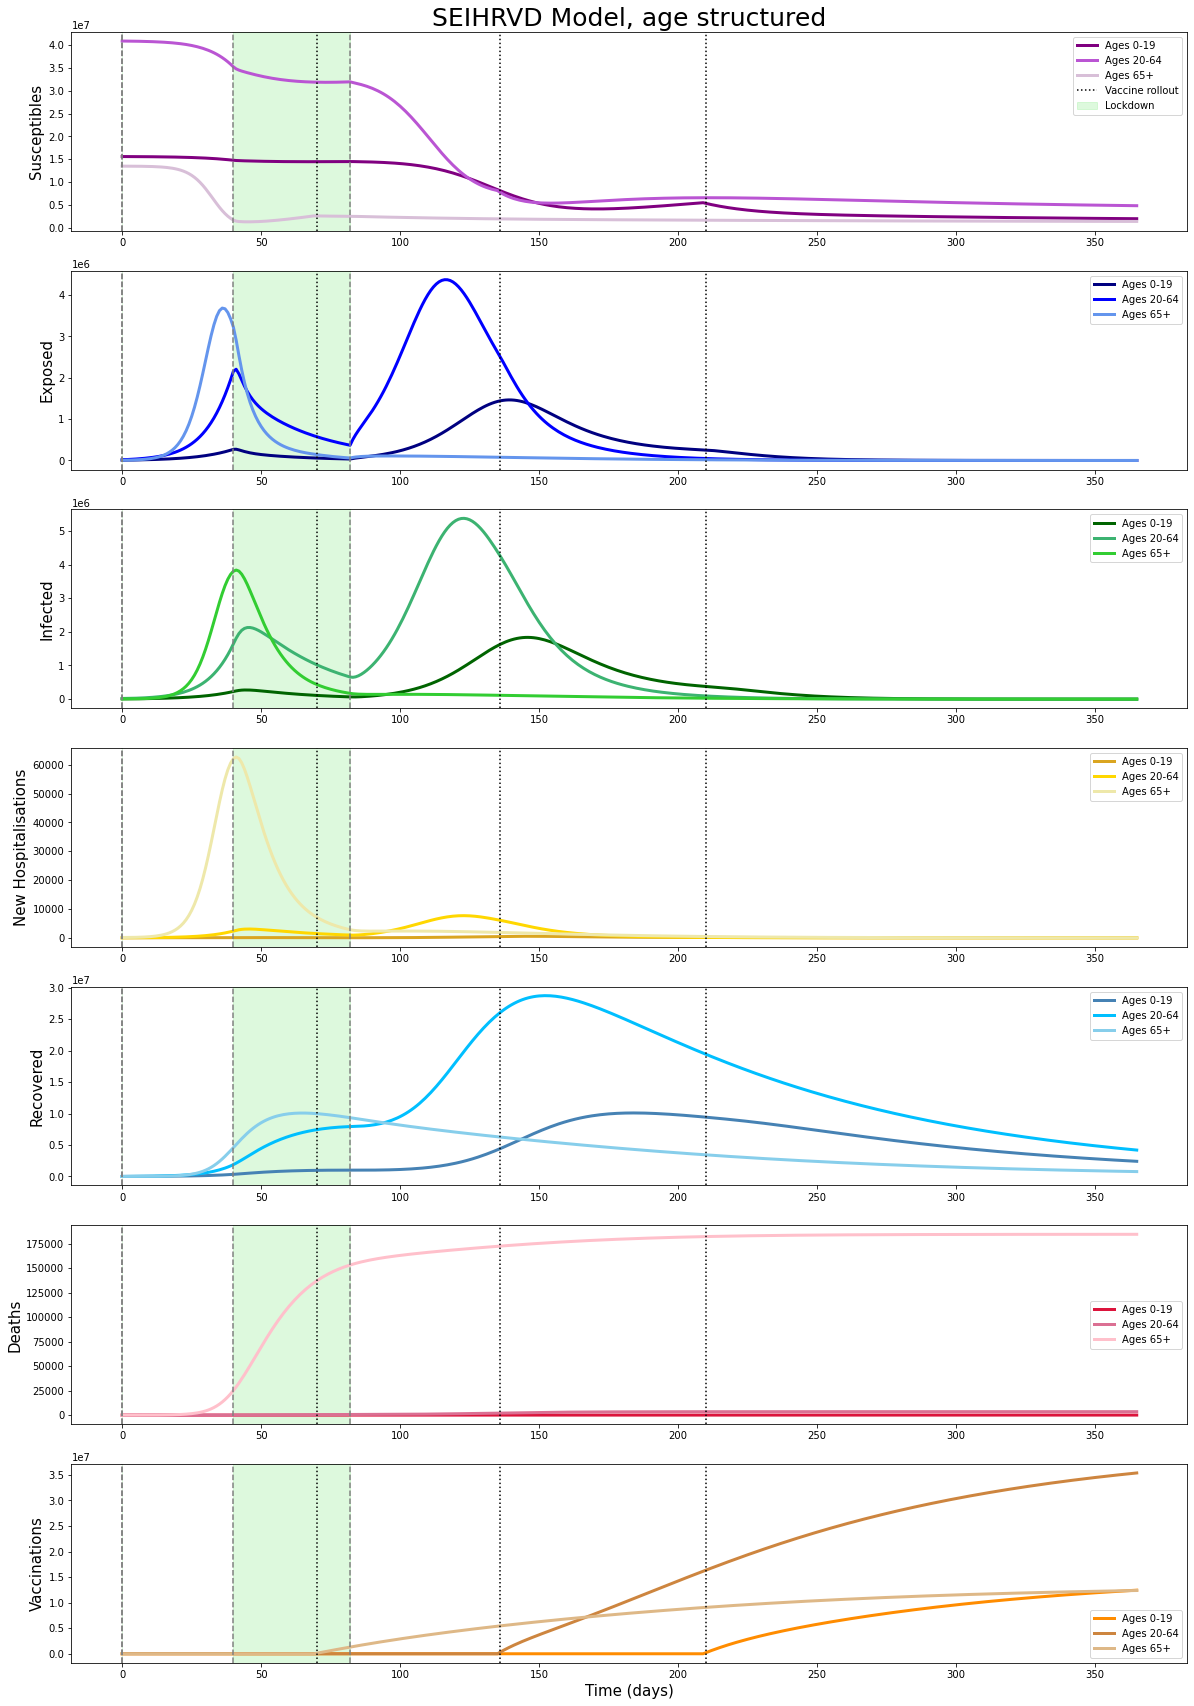

In [12]:
# Function to determine when vaccination should be rolled out for the given group 

def vaccinationDay(ageGrp, vaccineStart, eta, prop):
    sim = SEIHRVDsim_2LD(ageGrp, vaccineStart, eta, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End)

    totals, vaccImmune, hosp = sim.ODEsolver()
    
    dayToVaccinate = 0
    for day in range(ageGrp['days']):
        if totals[6][day] < prop*ageGrp['N']: # if number of vaccinations on  
            dayToVaccinate += 1

    if dayToVaccinate == ageGrp['days']:
        dayToVaccinate+=1
    return(dayToVaccinate)


# Parameters for intervention measures:
eta = 0.9
lockdown1Start = 40
lockdown1End = lockdown1Start + 6*7
lockdown2Start = 0
lockdown2End = 0
vaccineStart = 70
adultsVaccine = vaccinationDay(elderlyAgeGrp, vaccineStart, eta, 0.4)
childrenVaccine = vaccinationDay(adultAgeGrp, adultsVaccine, eta,0.4)


# Creating the objects for 3 different age groups
elderlySim = SEIHRVDsim_2LD(elderlyAgeGrp, vaccineStart, eta, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End)
adultSim = SEIHRVDsim_2LD(adultAgeGrp, adultsVaccine, eta, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End)
youngSim = SEIHRVDsim_2LD(youngAgeGrp, childrenVaccine, eta, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End)
totalsY, vaccImmuneY, hospitalisationsY = youngSim.ODEsolver()
totalsA, vaccImmuneA, hospitalisationsA = adultSim.ODEsolver()
totalsE, vaccImmuneE, hospitalisationsE = elderlySim.ODEsolver()



# Outbreak final numbers
print("For those 0-19 years old:")
youngSim.outbreakEndResults()
print("--------------------------")
print("For those 20-64 years old:")
adultSim.outbreakEndResults()
print("--------------------------")
print("For those aged 65+:")
elderlySim.outbreakEndResults()


# PLOTTING:
plt.figure(figsize=(20, 30))

plt.subplot(711) # SUSCEPTIBLES
plt.plot(totalsY[0], 'purple', linewidth = 3, label = 'Ages 0-19')
plt.plot(totalsA[0], 'mediumorchid', linewidth = 3, label = 'Ages 20-64')
plt.plot(totalsE[0], 'thistle', linewidth = 3, label = 'Ages 65+')
plt.axvline(vaccineStart, color = 'black', linestyle='dotted', label = 'Vaccine rollout')
plt.axvline(adultsVaccine, color = 'black', linestyle='dotted')
plt.axvline(childrenVaccine, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen', label = 'Lockdown')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.title('SEIHRVD Model, age structured', fontsize=25)
plt.legend(loc=0)
plt.ylabel('Susceptibles', fontsize=15)

plt.subplot(712) # EXPOSED
plt.plot(totalsY[1], 'navy', linewidth=3, label = 'Ages 0-19')
plt.plot(totalsA[1], 'blue', linewidth = 3, label='Ages 20-64')
plt.plot(totalsE[1], 'cornflowerblue', linewidth = 3, label='Ages 65+')
plt.axvline(vaccineStart, color = 'black', linestyle='dotted')
plt.axvline(adultsVaccine, color = 'black', linestyle='dotted')
plt.axvline(childrenVaccine, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Exposed', fontsize=15)

plt.subplot(713) # INFECTIOUS
plt.plot(totalsY[2], 'darkgreen', linewidth=3, label = 'Ages 0-19')
plt.plot(totalsA[2], 'mediumseagreen', linewidth = 3, label = 'Ages 20-64')
plt.plot(totalsE[2], 'limegreen', linewidth = 3, label = 'Ages 65+')
plt.axvline(vaccineStart, color = 'black', linestyle='dotted')
plt.axvline(adultsVaccine, color = 'black', linestyle='dotted')
plt.axvline(childrenVaccine, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Infected', fontsize=15)

plt.subplot(714) #HOSPITALISED
# plt.plot(totalsY[3], 'goldenrod', linewidth=3, label = 'Ages 0-19')
# plt.plot(totalsA[3], 'gold', linewidth = 3, label = 'Ages 20-64')
# plt.plot(totalsE[3], 'palegoldenrod', linewidth = 3, label = 'Ages 65+')
plt.plot(hospitalisationsY, 'goldenrod', linewidth=3, label = 'Ages 0-19')
plt.plot(hospitalisationsA, 'gold', linewidth = 3, label = 'Ages 20-64')
plt.plot(hospitalisationsE, 'palegoldenrod', linewidth = 3, label = 'Ages 65+')
plt.axvline(vaccineStart, color = 'black', linestyle='dotted')
plt.axvline(adultsVaccine, color = 'black', linestyle='dotted')
plt.axvline(childrenVaccine, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('New Hospitalisations', fontsize=15)

plt.subplot(715) # RECOVERED
plt.plot(totalsY[4], 'steelblue', linewidth=3, label = 'Ages 0-19')
plt.plot(totalsA[4], 'deepskyblue', linewidth = 3, label = 'Ages 20-64')
plt.plot(totalsE[4], 'skyblue', linewidth = 3, label = 'Ages 65+')
plt.axvline(vaccineStart, color = 'black', linestyle = 'dotted')
plt.axvline(adultsVaccine, color = 'black', linestyle='dotted')
plt.axvline(childrenVaccine, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Recovered', fontsize=15)

plt.subplot(716) # DEAD
plt.plot(totalsY[5], 'crimson', linewidth=3, label = 'Ages 0-19')
plt.plot(totalsA[5], 'palevioletred', linewidth = 3, label='Ages 20-64')
plt.plot(totalsE[5], 'pink', linewidth = 3, label='Ages 65+')
plt.axvline(vaccineStart, color = 'black', linestyle='dotted')
plt.axvline(adultsVaccine, color = 'black', linestyle='dotted')
plt.axvline(childrenVaccine, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Deaths', fontsize=15)

plt.subplot(717) # VACCINATED
plt.plot(totalsY[6], 'darkorange', linewidth = 3, label='Ages 0-19')
plt.plot(totalsA[6], 'peru', linewidth = 3, label='Ages 20-64')
plt.plot(totalsE[6], 'burlywood', linewidth = 3, label='Ages 65+')
plt.axvline(vaccineStart, color = 'black', linestyle='dotted')
plt.axvline(adultsVaccine, color = 'black', linestyle='dotted')
plt.axvline(childrenVaccine, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.xlabel('Time (days)', fontsize=15)
plt.ylabel('Vaccinations', fontsize = 15)

plt.show()